<a href="https://colab.research.google.com/github/juanepstein99/DI_Bootcamp/blob/main/Week12/Day4/DailyChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Daily Challenge: Logistic Regression for Admission Prediction**

**Your Task**

**Data Exploration: Load and visualize the data.**

* Use pandas to load the dataset and examine the first few rows.
* Create a scatter plot to visualize the data points for students who were admitted versus those who were not based on their exam scores.

**Applying Logistic Regression with scikit-learn:**

* Implement logistic regression using the LogisticRegression function from scikit-learn to find the best parameters for your model.
* Train the logistic regression model on your dataset.

**Making Predictions:**

* Use the trained logistic regression model to make predictions on your dataset.
* Calculate the accuracy of your model.

**Model Evaluation:**

* Interpret the result of logistic regression and the accuracy of your model.

In [1]:
#imports

import pandas as pd  # Dataframes
import numpy as np   # arrays
import matplotlib.pyplot as plt  # Visualization
import seaborn as sns            # Visualization
import sklearn                   # Machine Learning

from sklearn.model_selection import train_test_split   #split
from sklearn.preprocessing import StandardScaler  # scaling and encoding
from sklearn.linear_model import LogisticRegression  #Model

# confusion matrix & evaluation
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
    )

print("Libraries loaded!")

print(f"  Pandas  : {pd.__version__}")
print(f"  NumPy   : {np.__version__}")
print(f"  Seaborn : {sns.__version__}")
print(f"  Scikit-learn version: {sklearn.__version__}")

# Display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style('whitegrid')

Libraries loaded!
  Pandas  : 2.2.2
  NumPy   : 2.0.2
  Seaborn : 0.13.2
  Scikit-learn version: 1.6.1


In [2]:
df= pd.read_csv('ex2data1.txt', header=None, names=['exam1', 'exam2', 'admitted'])

print(df.shape)   #(100 students, 3 columns)
print()

display(df.head())

(100, 3)



,exam1,exam2,admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


In [5]:
print("Missing per column:")
display(df.isna().sum().sort_values(ascending=False))  #no missing

df.duplicated().sum()  #no duplicates

display(df.describe())

#scores fairly homogeneous between both exams

Missing per column:


,0
exam1,0
exam2,0
admitted,0


,exam1,exam2,admitted
count,100.000000,100.000000,100.000000
mean,65.644274,66.221998,0.600000
std,19.458222,18.582783,0.492366
min,30.058822,30.603263,0.000000
25%,50.919511,48.179205,0.000000
50%,67.032988,67.682381,1.000000
75%,80.212529,79.360605,1.000000
max,99.827858,98.869436,1.000000


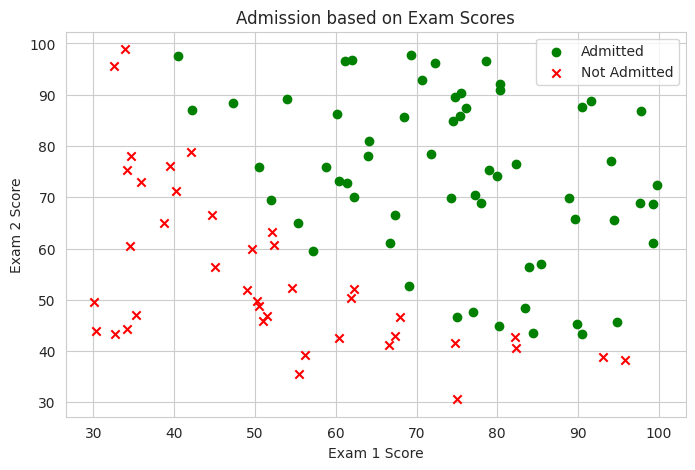

In [6]:
# Scatter plot: Admitted vs Not Admitted

admitted     = df[df['admitted'] == 1]
not_admitted = df[df['admitted'] == 0]

plt.scatter(admitted['exam1'],     admitted['exam2'],
            color='green', label='Admitted',     marker='o')
plt.scatter(not_admitted['exam1'], not_admitted['exam2'],
            color='red',   label='Not Admitted', marker='x')

plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.title('Admission based on Exam Scores')
plt.legend()
plt.show()

In [7]:
# Count Admitted & Not Admitted

class_names = {0:'No Admitted', 1:'Admitted'}

counts = df['admitted'].value_counts().rename(index=class_names)
percent = df['admitted'].value_counts(normalize=True).rename(index=class_names) * 100

df_summary = pd.DataFrame({
    'count': counts,
    'percentage': percent.round(2)
})

print(df_summary)

# 60% of the Students were admitted

             count  percentage
admitted                      
Admitted        60        60.0
No Admitted     40        40.0


**Preparation for Logistic Regression**

In [8]:
# separate y from x

X = df.drop(columns=['admitted'])   # X → variables
y = df['admitted']  # what I want to predict

display(X.head())
display(y.head())

,exam1,exam2
0,34.623660,78.024693
1,30.286711,43.894998
2,35.847409,72.902198
3,60.182599,86.308552
4,79.032736,75.344376


,admitted
0,0
1,0
2,0
3,1
4,1


In [9]:
# Split the data into train and test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,   # 80% training / 20% testing
    random_state=42,  #random seed
    stratify = y)  # same proportion of admitted in training and in test

print(X_train.shape, X_test.shape)

(80, 2) (20, 2)


In [10]:
# Scaling both exam's scores to Normal Distribution with mean = 0 and std = 1

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  #fit learns mean and std and apply transformation
X_test_scaled = scaler.transform(X_test)

print("\nmean", X_train_scaled.mean(axis=0).round(4))
print("std", X_train_scaled.std(axis=0).round(4))

print('''\nDataset ready for ML!
X_train_scaled
X_test_scaled
y_train
y_test''')


mean [-0.  0.]
std [1. 1.]

Dataset ready for ML!
X_train_scaled
X_test_scaled
y_train
y_test


In [11]:
# Logistic Regression Model | Training | Predicción

model =  LogisticRegression(max_iter= 1000)

model.fit(X_train_scaled, y_train.values.ravel())  #training part


# Making Predictions:
y_pred = model.predict(X_test_scaled)  #prediction part on unseen data

In [12]:
# Accuracy Manually
correct = (y_test == y_pred ).sum()
correct  #19 of 20 ~ 95%


np.int64(19)

In [13]:
# Model Evaluation

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {accuracy:.2%}")

# Full Report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['not_admitted', 'admitted']))

✅ Accuracy: 95.00%

📊 Classification Report:
              precision    recall  f1-score   support

not_admitted       0.89      1.00      0.94         8
    admitted       1.00      0.92      0.96        12

    accuracy                           0.95        20
   macro avg       0.94      0.96      0.95        20
weighted avg       0.96      0.95      0.95        20



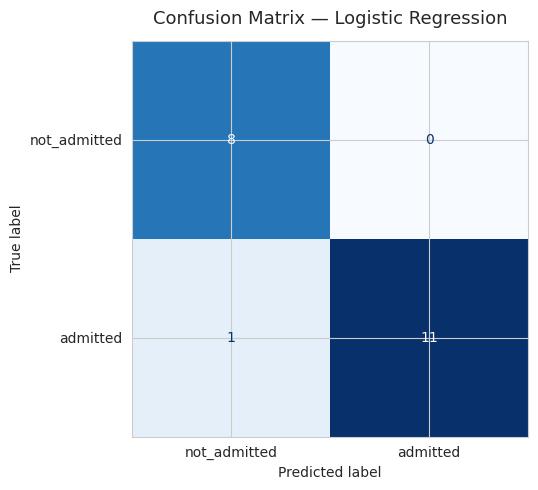

 True Negatives (TN): 8 → predicted 'not_admitted' and was correct
 False Positives (FP): 0 → predicted 'admitted' but they were not admitted 
 False Negatives (FN): 1 → predicted 'not_admitted' but they were admitted --> ⚠️ admitted not detected 
 True Positives (TP): 11 → predicted 'admitted' and was correct


In [14]:
# Confusion Matrix

fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['not_admitted', 'admitted'])
disp.plot(ax=ax, colorbar=False, cmap="Blues")

ax.set_title("Confusion Matrix — Logistic Regression", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# Breakdown to understand each cell
TN, FP, FN, TP = cm.ravel()
print(f" True Negatives (TN): {TN} → predicted 'not_admitted' and was correct")
print(f" False Positives (FP): {FP} → predicted 'admitted' but they were not admitted ")
print(f" False Negatives (FN): {FN} → predicted 'not_admitted' but they were admitted --> ⚠️ admitted not detected ")
print(f" True Positives (TP): {TP} → predicted 'admitted' and was correct")

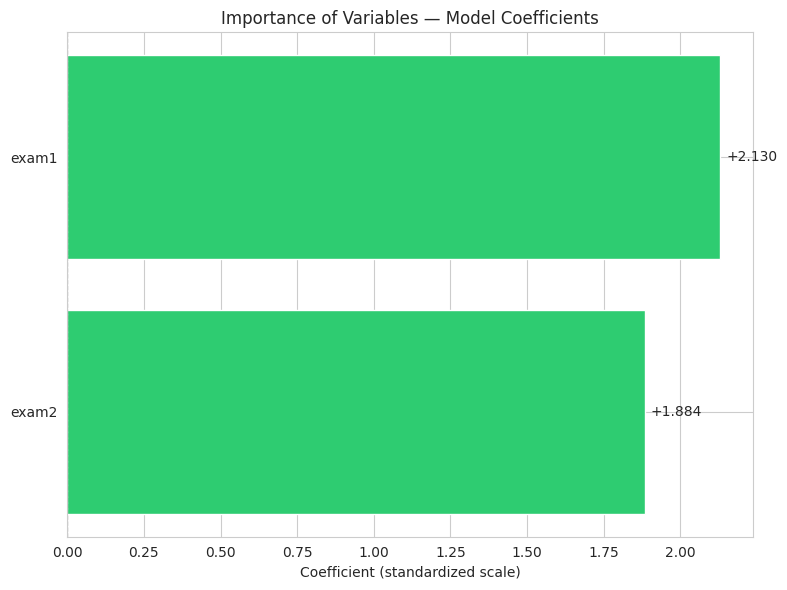

 exam2    → increases the probability of admission (coef: 1.884)
 exam1    → increases the probability of admission (coef: 2.130)


In [15]:
# IMPORTANCE OF FEATURES (coefficients)

features = X_train.columns.tolist()
coefs = model.coef_[0]

coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": coefs
}).sort_values("coefficient", ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#E74C3C" if c < 0 else "#2ECC71" for c in coef_df["coefficient"]]
bars = ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Importance of Variables — Model Coefficients", fontsize=12)
ax.set_xlabel("Coefficient (standardized scale)")

for bar, val in zip(bars, coef_df["coefficient"]):
    x_pos = val + 0.02 if val >= 0 else val - 0.02
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=10)

plt.tight_layout()
plt.show()

for _, row in coef_df.iterrows():
    direction = "increases" if row["coefficient"] > 0 else "reduces"
    print(f" {row['feature']:8s} → {direction} the probability of admission (coef: {row['coefficient']:.3f})")

# How you did on exam 1 is more important at the time of admission

**Insights**
**Model Evaluation**

* Accuracy: 95% — The model correctly classifies 19 out of 20 students.
* Precision: 100% — Every student predicted as admitted was actually admitted. Zero false alarms.
* Recall: 92% of admitted students were correctly detected. 1 admitted student was missed.
* F1: 96% — Excellent balance between precision and recall.

With only 100 students, a single misclassification has a big impact on metrics. Results should be interpreted with caution given the small dataset size.

**Logistic Regression**

* Both exam scores are positively correlated with admission probability.
* Exam 1 has a higher coefficient, making it the strongest predictor of admission.
* The model generalizes well despite the small dataset (100 students).